In [1]:
#############################################
# Notebook 05 – Hedonisches Regressionsmodell
# Projekt: Preisbewertung NL
#############################################

import sys
!{sys.executable} -m pip install statsmodels

import statsmodels.api as sm
import pandas as pd



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sk\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
# csv-Dateien laden

df_model = pd.read_csv('../data_clean/df_model_prepared.csv')
X = pd.read_csv('../data_clean/X_features.csv')
y = pd.read_csv('../data_clean/y_target.csv')


In [3]:
# Konstantenvektor hinzufügen

X_ols = sm.add_constant(X)


In [4]:
# Alle bool-Spalten in int umwandeln

bool_cols = X_ols.select_dtypes(include=['bool']).columns
X_ols[bool_cols] = X_ols[bool_cols].astype(int)


In [5]:
# OLS‑Modell schätzen
model = sm.OLS(y, X_ols).fit()


In [6]:
# Ergebnisse anzeigen

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        log_price_total   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     1131.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:39:35   Log-Likelihood:                 2433.2
No. Observations:                1690   AIC:                            -4826.
Df Residuals:                    1670   BIC:                            -4718.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

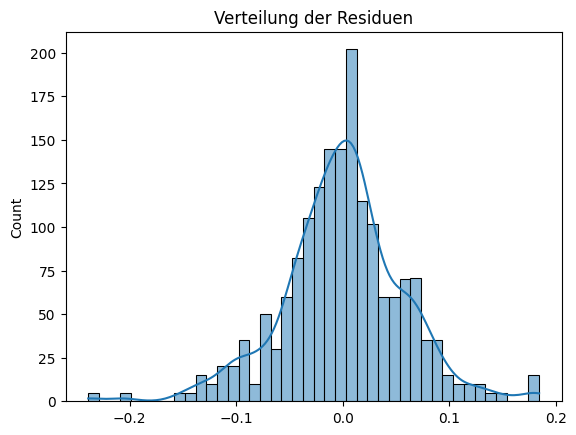

In [7]:
# Differenzen zwischen den tatsächlichen Werten und den vorhergesagten Werten prüfen

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(model.resid, kde=True)
plt.title("Verteilung der Residuen")
plt.show()
